# M4: LSTM

Ova sveska trenira i ocenjuje M4 LSTM nad sekvencama prethodno odigranih mečeva. LSTM je glavni model projekta.

Svaka rekurentna mreža ima svoju svesku, da bi se moglo raditi paralelno bez sudara u istom fajlu. Sve tri dele istu arhitekturu (`models.MatchPredictor`) i istu petlju treniranja (`train.train_model`) — razlikuje se samo parametar `cell`. Poređenje svih modela ide u svesku 05.

> **Trajanje.** Potpuno izvršavanje traje **oko 15 minuta**: sveska istrenira preko šezdeset modela, najviše u pretrazi hiperparametara i u ablaciji.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.config import (BATCH_SIZE, PROCESSED_DATA_PATH, RANDOM_STATE, RAW_STAT_COLUMNS,
                        RESULTS_FILE, SEQUENCE_FEATURE_COLUMNS)
from src import data, evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)

## Učitavanje sekvenci

Iste `sekvence.npz` i iste `train`/`validation` pozicije kao u svesci 02/03 - isti mečevi kao za M0-M3, kako bi poređenje bilo pošteno. Test skup se ovde ne učitava: dodiruje se tačno jednom, na kraju.

In [2]:
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
home_sequences, away_sequences = splits["home_sequences"], splits["away_sequences"]
context, labels = splits["context"], splits["labels"]
train_idx, validation_idx = splits["train"], splits["validation"]

home_train, away_train = home_sequences[train_idx], away_sequences[train_idx]
context_train, y_train = context[train_idx], labels[train_idx]

home_val, away_val = home_sequences[validation_idx], away_sequences[validation_idx]
context_val, y_val = context[validation_idx], labels[validation_idx]

home_train.shape, context_train.shape

((18092, 10, 8), (18092, 24))

## Dataset i DataLoader

`shuffle=True` meša samo redosled kojim mreža vidi već-fiksirane trening mečeve unutar jedne epohe - ne dira podelu na skupove, koja je hronološka i fiksirana još u svesci 02. Validacija se ne meša, jer se na njoj ne trenira.

In [3]:
dataset_train = sequences.MatchSequenceDataset(home_train, away_train, context_train, y_train)
dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

len(dataset_train), len(dataset_val)

(18092, 2624)

## Izbor hiperparametara

Vrednosti se biraju **pre** treniranja, jer sve što sledi zavisi od njih. Pretražuje se mreža iz `config.py`.

Pretragu izvodi `train.search_hyperparameters`, razlikuje se samo parametar `cell`.

Izbor ide po `roc_auc` na validaciji, jednim semenom.

In [4]:
rezultati_pretrage = train.search_hyperparameters(
    loader_train, loader_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="lstm",
)

rezultati_pretrage.head(5).round(4)

,hidden_size,dropout,learning_rate,tacnost,roc_auc,log_loss,brier
0,32,0.30,0.003,0.6566,0.6980,0.6174,0.2142
1,128,0.00,0.003,0.6547,0.6980,0.6172,0.2140
2,32,0.15,0.003,0.6566,0.6978,0.6187,0.2147
3,32,0.00,0.003,0.6543,0.6976,0.6178,0.2143
4,32,0.30,0.001,0.6532,0.6967,0.6183,0.2146


In [5]:
najbolji = rezultati_pretrage.iloc[0]

print(f"hidden_size   {int(najbolji['hidden_size'])}")
print(f"dropout       {najbolji['dropout']}")
print(f"learning_rate {najbolji['learning_rate']}")
print(f"roc_auc       {najbolji['roc_auc']:.4f}")

hidden_size   32
dropout       0.3
learning_rate 0.003
roc_auc       0.6980


Pobednik ima najveću stopu učenja iz mreže, `0.003`. Na samom kraju sveske se nalazi provera vrednosti izvan onih koje su definisane u `config.py`.

Zapaženo je da i kombinacije sa `dropout=0.00` daju praktično isti ROC-AUC (0.6980 i 0.6976) kao izabrana `0.30`.

Razlog je u tome gde dropout deluje. `MatchPredictor` ga primenjuje pre spajanja sa kontekstom, samo na izlaz enkodera — kontekst i Elo kroz njega uopšte ne prolaze. A ablacija niže pokazuje da baš taj deo ulaza ne doprinosi merljivo.

## Kreiranje mreže

`cell="lstm"` daje M4 LSTM.

`MatchPredictor` obrađuje sekvencu domaćina i sekvencu gosta **istom** ćelijom (deljene težine), uzima poslednje skriveno stanje svake kao naučeni sažetak forme, nalepi ih uz kontekst i propusti kroz jedan linearni sloj do sirovog logita.

In [6]:
train.set_seed(RANDOM_STATE)

model_lstm = models.MatchPredictor(
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="lstm",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
)
model_lstm


MatchPredictor(
  (encoder): LSTM(8, 32, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=88, out_features=1, bias=True)
)

## Treniranje mreže

In [7]:
history = train.train_model(
    model_lstm, loader_train, loader_val,
    epochs=100, patience=5, learning_rate=float(najbolji["learning_rate"]),
)

best_epoch = int(np.argmin(history["valid_loss"]))
print(f"trenirano {len(history['train_loss'])} epoha (rano zaustavljanje)")
print(
    f"najbolja epoha: {best_epoch + 1}, "
    f"validacija gubitak {history['valid_loss'][best_epoch]:.4f}, "
    f"validacija tacnost {history['valid_accuracy'][best_epoch]:.4f}"
)


trenirano 11 epoha (rano zaustavljanje)
najbolja epoha: 6, validacija gubitak 0.6174, validacija tacnost 0.6566


## Krive učenja

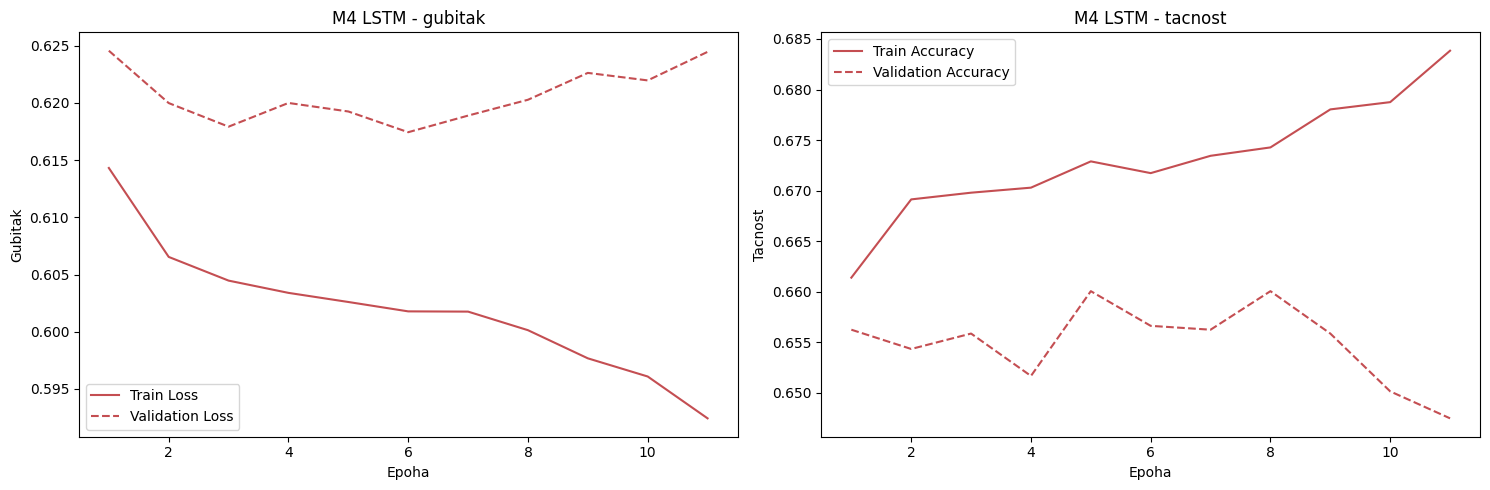

In [8]:
plotting.plot_learning_curves(history, "M4 LSTM")

Levi grafik, gubitak: Trening opada kroz sve epohe, validacija dostiže min u 6. i onda raste. Do 11. epohe validacioni gubitak (0.6245) se vratio tačno na vrednost iz prve epohe (0.6246) — deset epoha treniranja nije donelo ništa. Razmak se više nego utrostručuje, sa 0.010 na 0.032. Primećeno je preprilagođavanje i rano zaustavljanje ga hvata.

Desni grafik, tačnost: Validaciona kriva nema trend — oscilira između 0.6475 i 0.6601.

## Evaluacija modela

Matrica konfuzije, metrike po klasi i kalibracija na validaciji; zbirne metrike u `reports/rezultati.csv` — isti obrazac kao za M0-M2. Test skup se ne dodiruje ovde.

Tačnost je jedan broj za dva vrlo različita ponašanja, jer klase nisu u ravnoteži. Preciznost, odziv i F1 po klasi to razdvajaju.

In [9]:
for skup, loader in [("trening", loader_train), ("validacija", loader_val)]:
    y_proba, y_true = train.predict_proba(model_lstm, loader)
    metrike = evaluate.compute_metrics(y_true, y_proba)
    evaluate.append_results("M4 LSTM", skup, metrike)

pd.read_csv(RESULTS_FILE)

,model,skup,tacnost,roc_auc,log_loss,brier
0,M0 domacin,trening,0.599547,0.500000,14.433798,0.400453
1,M0 domacin,validacija,0.588796,0.500000,14.821304,0.411204
2,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
3,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363
4,M2 XGBoost,trening,0.683396,0.731799,0.590812,0.202857
5,M2 XGBoost,validacija,0.657012,0.699032,0.616667,0.213756
6,M4 LSTM,trening,0.676542,0.718328,0.599564,0.206640
7,M4 LSTM,validacija,0.656631,0.698018,0.617443,0.214206


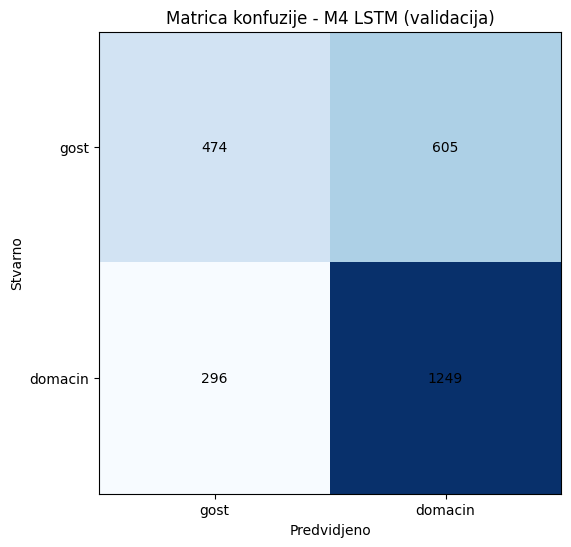

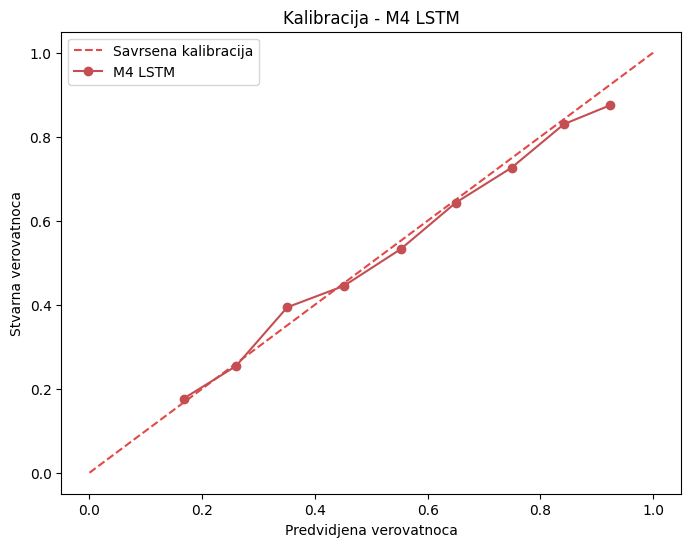

In [10]:
y_proba_val, y_true_val = train.predict_proba(model_lstm, loader_val)
y_pred_val = (y_proba_val >= 0.5).astype(int)

evaluate.plot_confusion_matrix(y_true_val, y_pred_val, "Matrica konfuzije - M4 LSTM (validacija)")
evaluate.plot_calibration_curve(y_true_val, y_proba_val, "M4 LSTM")

In [11]:
print(evaluate.compute_class_report(y_true_val, y_pred_val))

              precision    recall  f1-score   support

        gost      0.616     0.439     0.513      1079
     domacin      0.674     0.808     0.735      1545

    accuracy                          0.657      2624
   macro avg      0.645     0.624     0.624      2624
weighted avg      0.650     0.657     0.644      2624



**Model mnogo bolje pogađa domaćine nego goste.** Odziv je 0.808 za domaćine, a samo 0.439 za goste.

Preciznost za goste je 0.616: kad model kaže „gost", uglavnom je u pravu. Problem je što to retko kaže: domaćina prijavljuje na oko 71% mečeva, iako domaćin pobeđuje u 58.9%. Prag 0.5 nad neuravnoteženim klasama vuče predviđanja ka većoj klasi.

Zbog toga ROC-AUC, log-loss i Brier ostaju glavne metrike projekta. Tačnost, preciznost, odziv i F1 svi traže prag, a prag briše razliku između meča ocenjenog na 0.51 i onog na 0.95.Zadatak predviđa verovatnoću, ne odluku pa je model koji zna kad je nesiguran korisniji od onog koji uvek tvrdi isto. Pomeranjem praga na 0.55 bi se F1 promenio, a ROC-AUC ne bi, jer meri poredak preko svih pragova. 

Kalibracija pokazuje da model radi solidno: kad kaže 0.65, tačan je u oko 65% slučajeva.

## Ablacija: šta zapravo doprinosi rezultatu

M4 dobija dve vrste ulaza: sekvence prethodnih mečeva i kontekst tekućeg meča. Kontekst nosi skoro sve ono što koristi i M1 — Elo, međusobne duele i stanje na tabeli.

Pošto M4 završava blizu M1, prirodno je pitanje **koji deo mreže zapravo radi posao**. Meri se tako što se svaki ulaz redom zameni nulama, uz nepromenjenu arhitekturu.

Uz to se proverava i da li bi izlazna glava trebalo da ima skriveni sloj — jedina promena arhitekture koja bi joj omogućila da uči međudejstva forme i snage tima.

Sve varijante koriste **iste hiperparametre koje je izabrala pretraga**, pa je red „pun model" isti model kao M4 iznad.

In [12]:
class GlavaSaSkrivenimSlojem(models.MatchPredictor):
    """Ista mreza, ali izlaz ide kroz skriveni sloj umesto pravo u jedan Linear."""

    def __init__(self, n_features, n_context, cell="lstm", hidden_size=None, dropout=None):
        # bez podrazumevanih vrednosti - one bi se razisle sa izborom pretrage
        super().__init__(n_features, n_context, cell, hidden_size, dropout)
        self.output = nn.Sequential(
            nn.Linear(2 * hidden_size + n_context, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1),
        )


In [13]:
SEMENA = (7, 17, 27)

def ucitavaci(seme, bez_sekvenci=False, bez_konteksta=False, transform=None):
    """Vraca par ucitavaca u kojima je izabrani ulaz zamenjen nulama ili preobrazen.

    transform dobija i niz pozicija, da bi preobrazaj mogao da zavisi od toga
    kojoj sezoni mec pripada.
    """
    def skup(i):
        h, a, x, y = home_sequences[i], away_sequences[i], context[i], labels[i]
        if bez_sekvenci:
            h, a = np.zeros_like(h), np.zeros_like(a)
        if bez_konteksta:
            x = np.zeros_like(x)
        if transform is not None:
            h, a = transform(h, i), transform(a, i)
        return sequences.MatchSequenceDataset(h, a, x, y)

    generator = torch.Generator().manual_seed(seme)
    return (DataLoader(skup(train_idx), batch_size=BATCH_SIZE, shuffle=True, generator=generator),
            DataLoader(skup(validation_idx), batch_size=BATCH_SIZE, shuffle=False))


In [14]:
def oceni(klasa=models.MatchPredictor, learning_rate=None, **kw):
    """Trenira varijantu sa tri semena; vraca prosek, rasipanje i najvecu normu."""
    if learning_rate is None:
        learning_rate = float(najbolji["learning_rate"])

    tacnosti, auc, norme = [], [], []

    for seme in SEMENA:
        train.set_seed(seme)
        loader_t, loader_v = ucitavaci(seme, **kw)
        model = klasa(
            home_train.shape[-1], context_train.shape[-1], cell="lstm",
            hidden_size=int(najbolji["hidden_size"]), dropout=float(najbolji["dropout"]),
        )
        istorija = train.train_model(
            model, loader_t, loader_v, epochs=100, patience=5, learning_rate=learning_rate
        )
        proba, y = train.predict_proba(model, loader_v)
        metrike = evaluate.compute_metrics(y, proba)
        tacnosti.append(metrike["tacnost"])
        auc.append(metrike["roc_auc"])
        norme.append(max(istorija["grad_norm"]))

    return {"tacnost": np.mean(tacnosti), "rasipanje": np.std(tacnosti),
            "roc_auc": np.mean(auc), "max_norma": max(norme)}


In [15]:
varijante = {
    "pun model": dict(),
    "glava sa skrivenim slojem": dict(klasa=GlavaSaSkrivenimSlojem),
    "samo kontekst (sekvence = 0)": dict(bez_sekvenci=True),
    "samo sekvence (kontekst = 0)": dict(bez_konteksta=True),
}

pd.DataFrame(
    [oceni(**kw) for kw in varijante.values()], index=list(varijante)
)[["tacnost", "rasipanje", "roc_auc"]].round(4)


,tacnost,rasipanje,roc_auc
pun model,0.6557,0.0011,0.6964
glava sa skrivenim slojem,0.6529,0.0020,0.6957
samo kontekst (sekvence = 0),0.6571,0.0024,0.6963
samo sekvence (kontekst = 0),0.6294,0.0022,0.6638


**Skriveni sloj ne vredi.** Daje 0.6529, lošije od jednog `Linear`-a (0.6557). Pravilo postavljeno pre merenja tražilo je bar procenat dobitka — dobitka nema. Glava ostaje jedan `Linear`.

**Sekvence ne pomažu merljivo.** Bez njih model daje 0.6571, sa njima 0.6557. Razlika ide u korist modela *bez* sekvenci, ali je manja od rasipanja te varijante (0.0024) — pa se ne sme reći da sekvence odmažu, samo da ne pomažu.

**Sekvence ipak nisu prazne.** Same daju 0.6294, znatno iznad 0.5888 koliko daje „uvek domaćin". Nose signal o formi tima, ali ga Elo i tabela već sadrže, i to potpunije.

**Šta `rasipanje` znači.** Standardna devijacija po tri semena — koliko se ishod menja od pokretanja do pokretanja. Ne govori koliko bi se menjao na drugim mečevima i nije interval poverenja. Za red veličine je bolji podatak iz krivih učenja: isti model je kroz epohe oscilirao između 0.6475 i 0.6601. Razlike u tabeli su višestruko manje od toga.

**Red „pun model" nije isti broj kao M4 iznad** (0.6557 naspram 0.6566) jer je ovde prosek po tri semena, a M4 jedno pokretanje. Svi redovi koriste iste hiperparametre kao M4, pa se poredi arhitektura, a ne podešavanje.

### Na koliko mečeva se modeli uopšte razlikuju

Razlika od 0.14 procentnog poena je oko četiri meča od 2624. Vredi videti na koliko mečeva dva modela uopšte daju **različit** odgovor — koliko se preklapaju, a koliko stvarno takmiče.

Ovo je opis, ne test: samo prebrojavanje.

In [16]:
def predvidjanja(**kw):
    """Trenira jednu varijantu i vraca (predvidjeno, stvarno) na validaciji."""
    train.set_seed(RANDOM_STATE)
    loader_t, loader_v = ucitavaci(RANDOM_STATE, **kw)
    model = models.MatchPredictor(
        home_train.shape[-1], context_train.shape[-1], cell="lstm",
        hidden_size=int(najbolji["hidden_size"]), dropout=float(najbolji["dropout"]),
    )
    train.train_model(
        model, loader_t, loader_v,
        epochs=100, patience=5, learning_rate=float(najbolji["learning_rate"]),
    )
    proba, y = train.predict_proba(model, loader_v)
    return (proba >= 0.5).astype(int), y.astype(int)

In [17]:
pred_pun, y_val_bin = predvidjanja()
pred_bez, _ = predvidjanja(bez_sekvenci=True)

neslaganja = pred_pun != pred_bez
pun_u_pravu = int((neslaganja & (pred_pun == y_val_bin)).sum())
bez_u_pravu = int((neslaganja & (pred_bez == y_val_bin)).sum())

print(f"od {len(y_val_bin)} meceva modeli se razlikuju u {int(neslaganja.sum())}:")
print(f"  pun model u pravu {pun_u_pravu}, bez sekvenci u pravu {bez_u_pravu}")

od 2624 meceva modeli se razlikuju u 85:
  pun model u pravu 38, bez sekvenci u pravu 47


Modeli se slažu na 2539 od 2624 meča — **96.8%**. Na 85 mečeva na kojima se razilaze, varijanta bez sekvenci je u pravu na 47, pun model na 38: prednost od devet mečeva.

### Provera: covariate shift u sekvencama

Pošto je scaler prilagođen na sezone do 2016/17, a poeni su u međuvremenu porasli sa 94.9 na 114.9 (sveska 01), sekvence u kasnijim sezonama u mrežu ulaze sistematski pomerene. Elo i procenti pobeda tome ne podležu, jer su po konstrukciji nula-sume. To otvara mogućnost nezavisnog objašnjenja zašto rekurentna grana zaostaje.

In [18]:
pomak = pd.DataFrame({
    ime: [home_sequences[i][:, :, j].mean() for i in (train_idx, validation_idx)]
    for j, ime in enumerate(SEQUENCE_FEATURE_COLUMNS)
}, index=["trening", "validacija"]).T
pomak["pomak"] = pomak["validacija"] - pomak["trening"]
pomak.round(3)

,trening,validacija,pomak
PTS,-0.005,0.745,0.750
FG_PCT,0.001,0.115,0.114
FT_PCT,-0.001,0.115,0.116
FG3_PCT,0.001,0.047,0.046
AST,-0.003,0.452,0.455
REB,-0.007,0.330,0.338
WON,-0.003,-0.002,0.001
IS_HOME,-0.028,-0.032,-0.004


Pomak je stvaran i velik. Vrednosti su u skaliranom prostoru, pa se čitaju kao broj standardnih devijacija trening skupa: `PTS` se pomera za tri četvrtine standardne devijacije (0.750), `AST` za 0.455, `REB` za 0.338.

`WON` i `IS_HOME` se ne pomeraju (0.001 i −0.004), jer su po prirodi nula-sume — u svakom meču neko pobedi i neko je domaćin. Isto važi za Elo u kontekstu, koji je po konstrukciji preraspodela fiksnog zbira poena.

Ako je pomak zaista uzrok, uklanjanje nivoa iz sekvence bi trebalo da popravi rezultat. Ovde postoje dva različita načina:

- **Centriranje po sekvenci** svakoj sekvenci oduzima njen sopstveni prosek. Time nestaje pomak, ali i razlika između jakog i slabog tima, koja je stvaran signal a ne šum. Kako su ta dva efekta suprotnog znaka, nulti ishod sam po sebi ne dokazuje ništa.

- **Z-skor po sezoni**, s druge strane, oduzima prosek lige u toj sezoni i deli devijacijom lige — pomak nestaje, a razlika među timovima ostaje. Ovo je, dakle, test koji stvarno razdvaja te dve stvari.

(Napomena: z-skor koristi statistiku cele sezone odjednom, pa nije postupak primenljiv u stvarnom predviđanju unapred — ovde služi isključivo kao dijagnostika.)

In [19]:
# sezona svakog meca - treba z-skoru, jer se normalizuje u odnosu na ligu te sezone
df_games = data.clean_games(data.load_games())
sezone_svih = df_games.loc[splits["indices"], "SEASON"].to_numpy()

pd.DataFrame(
    [[int(sezone_svih[p].min()), int(sezone_svih[p].max()), len(np.unique(sezone_svih[p]))]
     for p in (train_idx, validation_idx)],
    columns=["prva sezona", "poslednja sezona", "broj sezona"],
    index=["trening", "validacija"],
)


,prva sezona,poslednja sezona,broj sezona
trening,2003,2016,14
validacija,2017,2018,2


In [20]:
# kolone koje driftuju se traze po imenu, ne po polozaju - redosled u
# SEQUENCE_FEATURE_COLUMNS sme da se promeni bez tihe greske ovde
DRIFTUJUCE = [SEQUENCE_FEATURE_COLUMNS.index(ime) for ime in RAW_STAT_COLUMNS]


def centriraj(s, pozicije=None):
    """Oduzima sopstveni prosek sekvence po koloni; uklanja i nivo tima."""
    s = s.copy()
    s[:, :, DRIFTUJUCE] -= s[:, :, DRIFTUJUCE].mean(axis=1, keepdims=True)
    return s


def z_skor_po_sezoni(s, pozicije):
    """Standardizuje u odnosu na ligu u toj sezoni; cuva razliku medju timovima."""
    s = s.copy()
    sezone = sezone_svih[pozicije]

    for sezona in np.unique(sezone):
        u_sezoni = sezone == sezona
        blok = s[u_sezoni]
        deo = blok[:, :, DRIFTUJUCE]
        blok[:, :, DRIFTUJUCE] = (deo - deo.mean(axis=(0, 1))) / deo.std(axis=(0, 1))
        s[u_sezoni] = blok

    return s


Pre merenja tačnosti, prvo proverimo da transformacija stvarno uklanja pomak. Jer ako pomak ostane, nulti rezultat ne govori ništa o hipotezi — govori samo da transformacija nije uspela.

In [21]:
def pomak_po_kolonama(transform=None):
    """Razlika prosecne vrednosti izmedju validacije i treninga, po kolonama."""
    h_trening, h_validacija = home_sequences[train_idx], home_sequences[validation_idx]
    if transform is not None:
        h_trening = transform(h_trening, train_idx)
        h_validacija = transform(h_validacija, validation_idx)
    return [h_validacija[:, :, j].mean() - h_trening[:, :, j].mean()
            for j in range(len(SEQUENCE_FEATURE_COLUMNS))]


pd.DataFrame({
    "sirovo": pomak_po_kolonama(),
    "centrirano": pomak_po_kolonama(centriraj),
    "z-skor po sezoni": pomak_po_kolonama(z_skor_po_sezoni),
}, index=SEQUENCE_FEATURE_COLUMNS).round(3)

,sirovo,centrirano,z-skor po sezoni
PTS,0.750,-0.000,-0.000
FG_PCT,0.114,-0.000,0.000
FT_PCT,0.116,-0.000,0.000
FG3_PCT,0.046,-0.000,-0.000
AST,0.455,-0.000,0.000
REB,0.338,0.000,0.000
WON,0.001,0.001,0.001
IS_HOME,-0.004,-0.004,-0.004


Obe transformacije rade ono što tvrde: pomak u kolonama koje driftuju pada sa 0.750 (`PTS`) na nulu. `WON` i `IS_HOME` ostaju nepromenjeni u sve tri kolone — oni nisu u `DRIFTUJUCE`, pa ova tabela usput potvrđuje i da se dira samo ono što treba.

Tek sad je nulti rezultat ispod čitljiv: ako tačnost ne poraste, to neće biti zato što pomak nije uklonjen.

In [22]:
pd.DataFrame(
    [oceni(**kw) for kw in (dict(), dict(transform=centriraj), dict(transform=z_skor_po_sezoni))],
    index=["sirove sekvence", "centrirane po sekvenci", "z-skor po sezoni"],
)[["tacnost", "rasipanje", "roc_auc"]].round(4)


,tacnost,rasipanje,roc_auc
sirove sekvence,0.6557,0.0011,0.6964
centrirane po sekvenci,0.6564,0.0015,0.6956
z-skor po sezoni,0.6561,0.0011,0.6963


**Hipoteza je odbačena.** Z-skor po sezoni daje 0.6561, sirove sekvence 0.6557 — razlika od 0.004 , unutar rasipanja. ROC-AUC je praktično isti.

 Centriranje daje sličan ishod (0.6564), ali iz njega se ne bi smelo zaključiti ništa, jer briše i pomak i razliku među timovima. Z-skor briše samo pomak.

Pomak dakle postoji, izmeren je i uklonjen — a rezultat se nije promenio. Nije uzrok zaostajanja rekurentne grane.

Ograničenje: uklonjen je pomak u **nivou** sirovih statistika. Ako se kroz sezone menja i sama dinamika forme, to bi ostalo nedirnuto.

### Provera ivice mreže

Izabrana stopa učenja `0.003` je najveća u mreži iz `config.py`. Pošto je izabrana stopa učenja na samoj granici početne mreže, izvršena je provera vrednosti van nje, za slučaj da je optimum negde izvan.

In [23]:
IVICA = (0.003, 0.006, 0.01, 0.02, 0.05)

pd.DataFrame(
    [oceni(learning_rate=lr) for lr in IVICA], index=[f"lr = {lr}" for lr in IVICA]
).round(4)

,tacnost,rasipanje,roc_auc,max_norma
lr = 0.003,0.6557,0.0011,0.6964,1.2231
lr = 0.006,0.6580,0.0010,0.6972,1.1893
lr = 0.01,0.6566,0.0016,0.6972,1.3189
lr = 0.02,0.6535,0.0040,0.6932,1.5166
lr = 0.05,0.6562,0.0031,0.6902,2.0462


Optimum je nešto izvan mreže, ali plitko: `0.006` daje 0.6580 naspram 0.6557, dobitak od 0.0023. Iznad `0.01` se kvari — ROC-AUC pada na 0.690, rasipanje se utrostručuje.

## Čuvanje modela

 Čuva se stanje sa najmanjim validacionim gubitkom, `train_model` vraća model sa učitanim najboljim težinama.

In [24]:
train.save_model(model_lstm, "lstm.pt")

## Zaključak

M4 LSTM daje **65.7% tačnosti** na validaciji, uz ROC-AUC 0.698, log-gubitak 0.617 i Brier 0.214, sa hiperparametrima koje je izabrala pretraga: `hidden_size=32`, `dropout=0.3`, `learning_rate=0.003`. 

**Glavni nalaz sveske:** sekvence prethodnih mečeva ne donose merljivo poboljšanje preko onoga što Elo i tabela već nose. Model sa sekvencama i model bez njih slažu se na 96.8% mečeva, a tamo gde se razilaze dele se skoro na pola. Sekvence same nose signal — 62.9% naspram 58.9% koliko daje „uvek domaćin" — ali taj signal je redundantan.

Covariate shift je proveren kao nezavisno objašnjenje i **odbačen**: uklanjanje pomaka z-skorom po sezoni ne menja rezultat.

**Model je asimetričan** — odziv iznosi 0.808 za domaćine, a svega 0.439 za goste. Preciznost za goste je 0.616, ali model i pored toga prijavljuje pobedu domaćina na oko 71% mečeva.

Pretraga je izabrala upola manji enkoder (32 umesto polaznih 64) i tri puta veću stopu učenja. Manji enkoder se dobro uklapa u nalaz ablacije: što manje dimenzija dolazi iz sekvenci, to manje toga izlazni sloj mora da nauči da zanemari. Sam izbor ipak nije oštar — prva dva mesta u pretrazi razlikuju se za svega 0.000055 ROC-AUC, iako su u pitanju bitno različite mreže (32 naspram 128 jedinica).

Treniranje je stalo na 11. epohi, sa najboljim stanjem sačuvanim u 6. Mreža ima 5 465 parametara nad 18 092 primera, od čega 5 376 otpada na enkoder a svega 89 na izlazni sloj, a razmak između treninga i validacije ostaje mali (67.7% naspram 65.7%).